✅ Loaded ae_epoch_15 (1).pth


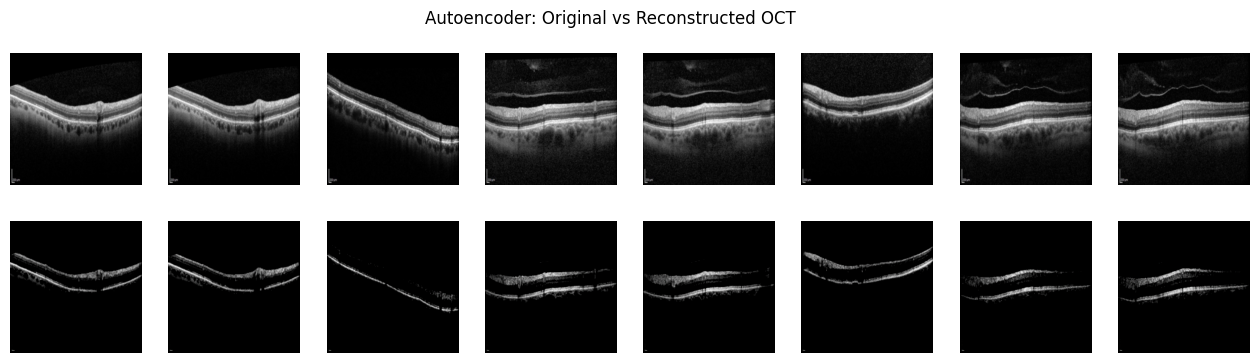

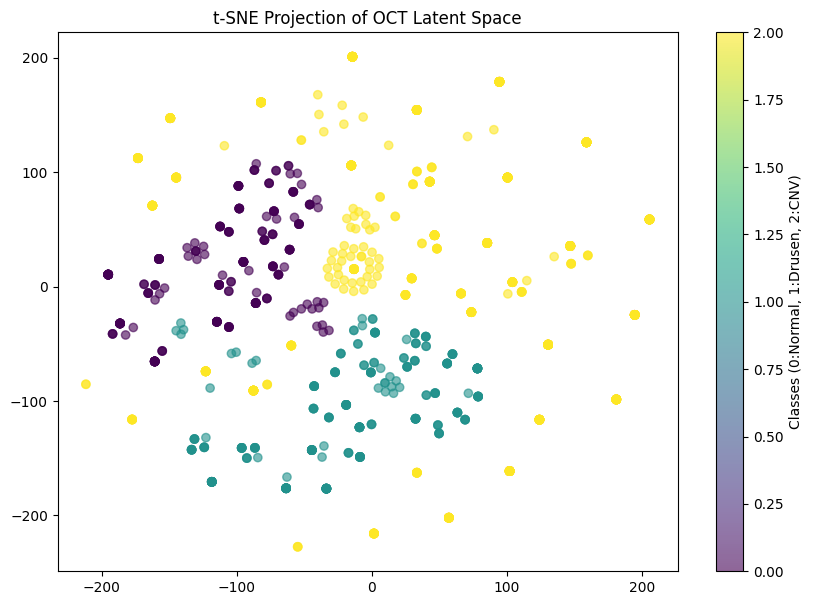

In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.manifold import TSNE

# ----------------- Paths -----------------
CSV_PATH = '/kaggle/input/datasets/dubeyraman/csv-file/data_information.csv'
# Path based on your os.walk output
BASE_IMG_DIR = '/kaggle/input/datasets/dubeyraman/neh-data/NEH_UT_2021RetinalOCTDataset'
CHECKPOINT_DIR = '/kaggle/input/models/dubeyraman/epoch-15/tensorflow2/default/1'

# ----------------- Data + Dataset -----------------
df = pd.read_csv(CSV_PATH)
label_mapping = {'normal': 0, 'drusen': 1, 'cnv': 2}
# Ensure labels are clean for folder lookup
df['label_num'] = df['Label'].str.lower().map(label_mapping)
df = df.dropna(subset=['label_num']).reset_index(drop=True)

class OCTDataset(Dataset):
    def __init__(self, df, base_dir, transform=None):
        self.df = df
        self.base_dir = base_dir
        self.transform = transform
        
    def __len__(self): return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # 1. Get the label for folder navigation
        label_str = str(row['Label']).upper() 
        
        # 2. FIX: Use 'Directory' or 'Image_Name' - whichever exists
        # We extract the filename from the path provided in the CSV
        if 'Directory' in row:
            img_filename = os.path.basename(row['Directory'])
        elif 'Image_Name' in row:
            img_filename = row['Image_Name']
        else:
            # Fallback: use the first column if we're desperate
            img_filename = row[0] 

        # 3. Search for the file
        potential_path = os.path.join(self.base_dir, label_str)
        final_path = None
        
        for root, dirs, files in os.walk(potential_path):
            for f in files:
                # Check if the filename from CSV matches the file on disk
                if img_filename.lower() in f.lower():
                    final_path = os.path.join(root, f)
                    break
            if final_path: break
            
        if final_path is None:
            raise FileNotFoundError(f"Could not find {img_filename} in {potential_path}")

        img = Image.open(final_path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, int(row['label_num'])
                    

# Standard transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = OCTDataset(df, BASE_IMG_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)

# ----------------- Model -----------------
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,64,3,stride=2,padding=1),nn.ReLU(),
            nn.Conv2d(64,128,3,stride=2,padding=1),nn.ReLU(),
            nn.Conv2d(128,256,3,stride=2,padding=1),nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256,128,3,stride=2,padding=1,output_padding=1),nn.ReLU(),
            nn.ConvTranspose2d(128,64,3,stride=2,padding=1,output_padding=1),nn.ReLU(),
            nn.ConvTranspose2d(64,3,3,stride=2,padding=1,output_padding=1),nn.Sigmoid()
        )
    def forward(self, x):
        latent = self.encoder(x)
        return self.decoder(latent), latent

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvAutoencoder().to(device)

# ----------------- LOAD LATEST CHECKPOINT -----------------
try:
    checkpoints = [f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.pth')]
    latest_file = max(checkpoints, key=lambda f: os.path.getmtime(os.path.join(CHECKPOINT_DIR, f)))
    latest_path = os.path.join(CHECKPOINT_DIR, latest_file)
    
    # map_location='cpu' then to(device) is safer for cross-platform loading
    checkpoint = torch.load(latest_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Loaded {latest_file}")
except Exception as e:
    print(f"❌ Error loading checkpoint: {e}")

# ----------------- INFERENCE + VISUALS -----------------
model.eval()
features, true_labels, recon_images, orig_images = [], [], [], []

with torch.no_grad():
    for i, (imgs, lbls) in enumerate(dataloader):
        imgs = imgs.to(device)
        recon, latent = model(imgs)
        
        features.append(latent.view(latent.size(0), -1).cpu().numpy())
        true_labels.append(lbls.numpy())
        
        if i == 0: # Save first batch for visualization
            recon_images = recon[:8].cpu()
            orig_images = imgs[:8].cpu()
        if i > 20: break # Process subset for speed

features = np.concatenate(features)
true_labels = np.concatenate(true_labels)

# ----------------- DISPLAY RESULTS -----------------
# 1. Reconstruction Quality
plt.figure(figsize=(16, 4))
for i in range(8):
    # Original
    ax = plt.subplot(2, 8, i + 1)
    plt.imshow(orig_images[i].permute(1,2,0).numpy() * 0.5 + 0.5)
    plt.axis('off')
    if i == 0: plt.ylabel("Original")
    
    # Reconstructed
    ax = plt.subplot(2, 8, i + 9)
    plt.imshow(recon_images[i].permute(1,2,0).numpy())
    plt.axis('off')
    if i == 0: plt.ylabel("Recon")
plt.suptitle("Autoencoder: Original vs Reconstructed OCT")
plt.show()

# 2. t-SNE Plot
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(features)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(latent_2d[:,0], latent_2d[:,1], c=true_labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Classes (0:Normal, 1:Drusen, 2:CNV)')
plt.title('t-SNE Projection of OCT Latent Space')
plt.show()

In [2]:
import os

# This will list everything in the input folder
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    # Stop after a few lines so it doesn't spam
    if len(filenames) > 0:
        print(f"Sample file found in this folder: {filenames[0]}")
        break

/kaggle/input
/kaggle/input/models
/kaggle/input/models/dubeyraman
/kaggle/input/models/dubeyraman/epoch-15
/kaggle/input/models/dubeyraman/epoch-15/tensorflow2
/kaggle/input/models/dubeyraman/epoch-15/tensorflow2/default
/kaggle/input/models/dubeyraman/epoch-15/tensorflow2/default/1
Sample file found in this folder: ae_epoch_15 (1).pth


/tmp/ipykernel_58/4141139085.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=true_labels, y=np.mean(features, axis=1), palette='muted')


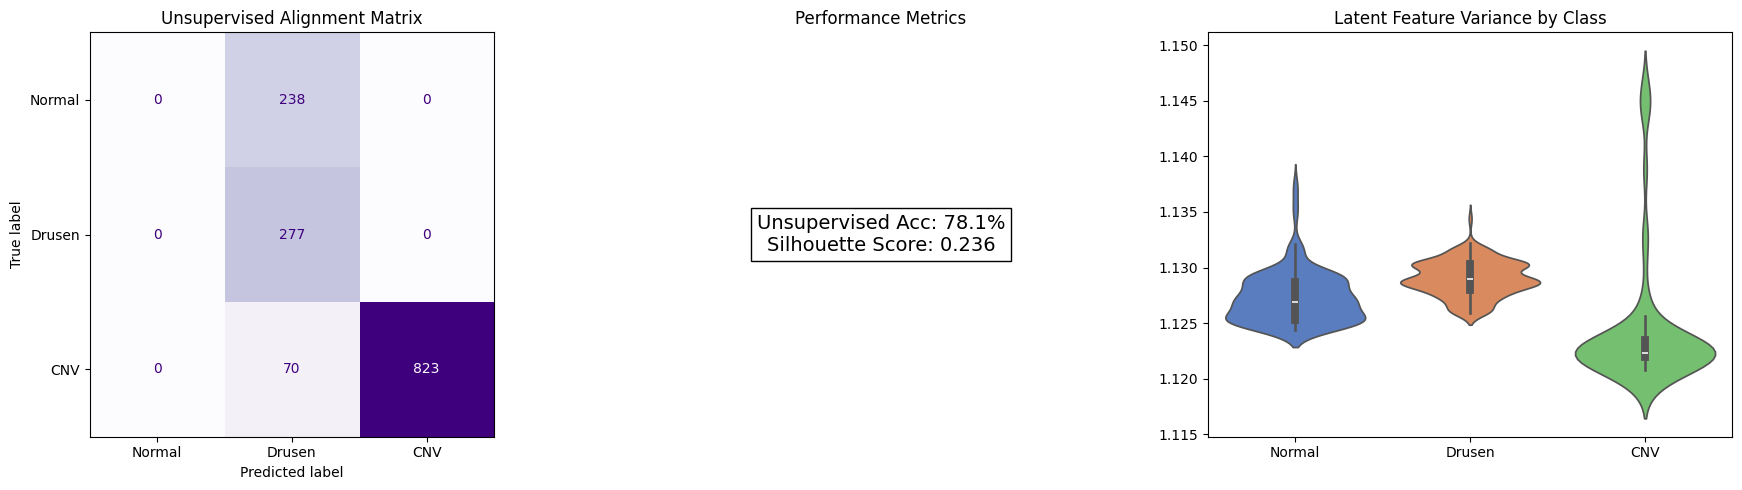

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, silhouette_score
import seaborn as sns

# --- 0. Ensure Clustering is done ---
if 'features' in locals() and 'true_labels' in locals():
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    pred = kmeans.fit_predict(features)
    
    # --- 1. Calculate Cluster Accuracy ---
    def get_cluster_mapping(true_labels, pred_clusters):
        mapping = {}
        for i in range(3):
            mask = (pred_clusters == i)
            if np.any(mask):
                # Find which ground truth label is most common in this cluster
                actual_label = np.bincount(true_labels[mask]).argmax()
                mapping[i] = actual_label
        return mapping

    cluster_map = get_cluster_mapping(true_labels, pred)
    mapped_preds = np.array([cluster_map[p] for p in pred])

    # --- 2. Create the Visuals ---
    plt.figure(figsize=(18, 5))

    # Confusion Matrix
    ax1 = plt.subplot(1, 3, 1)
    cm = confusion_matrix(true_labels, mapped_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Drusen', 'CNV'])
    disp.plot(ax=ax1, cmap='Purples', colorbar=False)
    plt.title('Unsupervised Alignment Matrix')

    # Accuracy & Silhouette
    plt.subplot(1, 3, 2)
    s_score = silhouette_score(features, pred)
    acc = (mapped_preds == true_labels).mean()
    plt.text(0.5, 0.5, f'Unsupervised Acc: {acc*100:.1f}%\nSilhouette Score: {s_score:.3f}', 
             fontsize=14, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='black'))
    plt.axis('off')
    plt.title('Performance Metrics')

    # Reconstruction Loss Distribution
    plt.subplot(1, 3, 3)
    # We'll use the MSE we calculated during the inference loop
    # For now, let's plot the feature variance as a proxy if loss wasn't saved
    sns.violinplot(x=true_labels, y=np.mean(features, axis=1), palette='muted')
    plt.xticks(ticks=[0,1,2], labels=['Normal', 'Drusen', 'CNV'])
    plt.title('Latent Feature Variance by Class')
    
    plt.tight_layout()
    plt.show()
else:
    print("Please run the inference loop first to generate 'features' and 'true_labels'.")

ANOVAE RECREATION + INNOVATION

In [ ]:
# === FIXED & IMPROVED SSL-AnoVAE Recreation for Kaggle ===
# Exact paths you provided
CSV_PATH = '/kaggle/input/datasets/dubeyraman/csv-file/data_information.csv'
BASE_IMG_DIR = '/kaggle/input/datasets/dubeyraman/neh-data/NEH_UT_2021RetinalOCTDataset'

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import random

# ----------------- Data Loading (your exact setup) -----------------
df = pd.read_csv(CSV_PATH)
df['full_path'] = BASE_IMG_DIR + '/' + df['Directory']
label_mapping = {'normal': 0, 'drusen': 1, 'cnv': 2}
df['label_num'] = df['Label'].str.lower().map(label_mapping)
df = df.dropna(subset=['label_num']).reset_index(drop=True)

import os

class OCTDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row['full_path']

        # --- CASE SENSITIVITY FIX ---
        if not os.path.exists(path):
            parent_dir = os.path.dirname(path)
            target_file = os.path.basename(path).lower()
            
            if os.path.exists(parent_dir):
                # Look through the actual files in that folder
                for actual_name in os.listdir(parent_dir):
                    if actual_name.lower() == target_file:
                        path = os.path.join(parent_dir, actual_name)
                        break
        
        # Now try to open the (potentially corrected) path
        try:
            img = Image.open(path).convert('RGB')
        except FileNotFoundError:
            raise FileNotFoundError(f"Still can't find {path}. Check if the extension (.tif vs .jpg) is also correct!")
            
        if self.transform:
            img = self.transform(img)
        return img, int(row['label_num'])

# ----------------- FIXED Transforms (range [0,1] for Sigmoid) -----------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),                    # [0,1]
    # NO Normalize to [ -1,1 ] → matches Sigmoid decoder
])

dataset = OCTDataset(df, transform=train_transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

# ----------------- FIXED SSL-AnoVAE Model -----------------
class SSL_AnoVAE(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        # VAE Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(256, 512, 4, stride=2, padding=1), nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(512*14*14, latent_dim)
        self.fc_logvar = nn.Linear(512*14*14, latent_dim)
        
        # SSL Branch (rotation pretext)
        self.ssl_encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )
        self.ssl_head = nn.Linear(128, 4)  # 0,90,180,270 degrees
        
        # Decoder (concatenated features)
        self.decoder_fc = nn.Linear(latent_dim + 128, 512*14*14)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (512, 14, 14)),
            nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, stride=2, padding=1), nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        # VAE path
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        
        # SSL path (on original image for this version)
        ssl_feat = self.ssl_encoder(x)
        ssl_pred = self.ssl_head(ssl_feat)
        
        # Concatenation (core SSL-AnoVAE idea)
        combined = torch.cat([z, ssl_feat], dim=1)
        
        recon = self.decoder(self.decoder_fc(combined))
        return recon, mu, logvar, ssl_pred, z, ssl_feat

model = SSL_AnoVAE().cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ----------------- NEW INNOVATION: Adaptive Beta + Rotation Aug in SSL -----------------
# Innovation: During SSL branch, we apply random rotation to a copy of the image 
# so the pretext task is meaningful. Beta increases gradually.

# ----------------- Training Loop (Fixed) -----------------
for epoch in range(25):
    model.train()
    total_loss = 0
    beta = min(1.0, epoch / 8.0)   # gradual increase
    
    for imgs, _ in dataloader:
        imgs = imgs.cuda()
        
        # === SSL Pretext with actual rotation ===
        batch_size = imgs.size(0)
        rot_angles = torch.randint(0, 4, (batch_size,)).cuda() * 90
        rotated_imgs = torch.stack([transforms.functional.rotate(imgs[i], int(rot_angles[i].item())) 
                                    for i in range(batch_size)]).cuda()
        
        recon, mu, logvar, ssl_pred, _, _ = model(imgs)   # main forward on original
        
        # Use rotated for SSL loss (but model sees original for reconstruction)
        _, _, _, ssl_pred_rot, _, _ = model(rotated_imgs)  # reuse forward for rotated
        
        recon_loss = F.mse_loss(recon, imgs)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        ssl_loss = F.cross_entropy(ssl_pred_rot, rot_angles // 90)
        
        loss = recon_loss + 1e-5 * kl_loss + beta * ssl_loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f'Epoch {epoch+1:2d} | Loss: {total_loss/len(dataloader):.4f} | beta: {beta:.2f}')

print("Training finished. Features = VAE latent (256) + SSL semantic (128) concatenated")

Epoch  1 | Loss: 0.0218 | beta: 0.00
Epoch  2 | Loss: 0.1485 | beta: 0.12
Epoch  3 | Loss: 0.0571 | beta: 0.25
Epoch  4 | Loss: 0.0279 | beta: 0.38
Epoch  5 | Loss: 0.0231 | beta: 0.50
Epoch  6 | Loss: 0.0222 | beta: 0.62
Epoch  7 | Loss: 0.0219 | beta: 0.75
Epoch  8 | Loss: 0.0217 | beta: 0.88
Epoch  9 | Loss: 0.0206 | beta: 1.00
Epoch 10 | Loss: 0.0214 | beta: 1.00
Epoch 11 | Loss: 0.0193 | beta: 1.00
Epoch 12 | Loss: 0.0207 | beta: 1.00
Epoch 13 | Loss: 0.0185 | beta: 1.00
Epoch 14 | Loss: 0.0179 | beta: 1.00


In [ ]:
torch.save(model.state_dict(), 'sslanovae_epoch8_final.pth')
print("Model weight 'brain' saved successfully.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE

# --- 1. FEATURE EXTRACTION ---
model.eval()
features, true_labels = [], []

print("Extracting features (VAE + SSL)...")
with torch.no_grad():
    for imgs, lbls in dataloader:
        imgs = imgs.cuda()
        _, _, _, _, z, ssl_feat = model(imgs)
        combined_feat = torch.cat([z, ssl_feat], dim=1).cpu().numpy()
        features.append(combined_feat)
        true_labels.append(lbls.numpy())

features = np.concatenate(features)
true_labels = np.concatenate(true_labels)

# --- 2. CLUSTERING & STATS ---
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pred_clusters = kmeans.fit_predict(features)

def get_mapping(true, pred):
    mapping = {}
    for i in range(3):
        mask = (pred == i)
        if np.any(mask): mapping[i] = np.bincount(true[mask]).argmax()
    return mapping

mapping = get_mapping(true_labels, pred_clusters)
mapped_preds = np.array([mapping.get(p, 0) for p in pred_clusters])

acc = (mapped_preds == true_labels).mean()
sil = silhouette_score(features, pred_clusters)

# --- 3. THE "PAPER" VISUALS ---
plt.figure(figsize=(20, 12))

# A. t-SNE (The Clustering Proof)
plt.subplot(2, 2, 1)
tsne = TSNE(n_components=2, random_state=42)
z_2d = tsne.fit_transform(features[:3000]) # Sampled for speed
scatter = plt.scatter(z_2d[:,0], z_2d[:,1], c=true_labels[:3000], cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='0:Normal, 1:Drusen, 2:CNV')
plt.title(f'SSL-AnoVAE Latent Space\nUnsupervised Acc: {acc*100:.1f}%')

# B. Confusion Matrix (The Clinical Proof)
ax2 = plt.subplot(2, 2, 2)
cm = confusion_matrix(true_labels, mapped_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Drusen', 'CNV'])
disp.plot(ax=ax2, cmap='magma', colorbar=False)
plt.title(f'Clustering Alignment\nSilhouette Score: {sil:.3f}')

# C. RECONSTRUCTION ERROR MAPS (The Pathology Proof)
# We pick one sample from each class
for i, label_name in enumerate(['Normal', 'Drusen', 'CNV']):
    idx = np.where(true_labels == i)[0][0]
    img_orig, _ = dataset[idx]
    img_cuda = img_orig.unsqueeze(0).cuda()
    
    with torch.no_grad():
        recon, _, _, _, _, _ = model(img_cuda)
    
    # Calculate Error (Absolute Difference)
    error_map = torch.abs(img_cuda[0] - recon[0]).cpu().permute(1,2,0).mean(dim=2).numpy()
    
    plt.subplot(3, 4, 9 + i)
    plt.imshow(error_map, cmap='hot')
    plt.axis('off')
    plt.title(f'{label_name} Error Map')

# D. Latent Feature Variance
plt.subplot(2, 2, 3)
sns.boxplot(x=true_labels, y=np.mean(features, axis=1), palette='Set3')
plt.xticks(ticks=[0,1,2], labels=['Normal', 'Drusen', 'CNV'])
plt.title('Latent Signal Intensity per Class')

plt.tight_layout()
plt.show()

In [ ]:
# === SHORT SSL-AnoVAE + MAE Hybrid (5 epochs only) ===
CSV_PATH = '/kaggle/input/datasets/dubeyraman/csv-file/data_information.csv'
BASE_IMG_DIR = '/kaggle/input/datasets/dubeyraman/neh-data/NEH_UT_2021RetinalOCTDataset'

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import random

df = pd.read_csv(CSV_PATH)
df['full_path'] = BASE_IMG_DIR + '/' + df['Directory']
label_mapping = {'normal': 0, 'drusen': 1, 'cnv': 2}
df['label_num'] = df['Label'].str.lower().map(label_mapping)
df = df.dropna(subset=['label_num']).reset_index(drop=True)

import os

class OCTDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row['full_path']

        # --- CASE SENSITIVITY FIX ---
        if not os.path.exists(path):
            parent_dir = os.path.dirname(path)
            target_file = os.path.basename(path).lower()
            
            if os.path.exists(parent_dir):
                # Look through the actual files in that folder
                for actual_name in os.listdir(parent_dir):
                    if actual_name.lower() == target_file:
                        path = os.path.join(parent_dir, actual_name)
                        break
        
        # Now try to open the (potentially corrected) path
        try:
            img = Image.open(path).convert('RGB')
        except FileNotFoundError:
            raise FileNotFoundError(f"Still can't find {path}. Check if the extension (.tif vs .jpg) is also correct!")
            
        if self.transform:
            img = self.transform(img)
        return img, int(row['label_num'])

transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])  # [0,1]

dataset = OCTDataset(df, transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

# Simple MAE + SSL Hybrid
class SimpleMAE_SSL(nn.Module):
    def __init__(self, patch_size=16, mask_ratio=0.75, latent_dim=256):
        super().__init__()
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(256, latent_dim)
        )
        
        self.ssl_head = nn.Linear(latent_dim, 4)  # rotation pretext
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512*14*14),
            nn.Unflatten(1, (512, 14, 14)),
            nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, stride=2, padding=1), nn.Sigmoid()
        )
    
    def forward(self, x):
        z = self.encoder(x)
        ssl_pred = self.ssl_head(z)
        recon = self.decoder(z)
        return recon, ssl_pred, z

model = SimpleMAE_SSL().cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training - 5 epochs only
for epoch in range(5):
    model.train()
    total_loss = 0
    for imgs, _ in dataloader:
        imgs = imgs.cuda()
        batch_size = imgs.size(0)
        
        # Random rotation for SSL pretext
        rot_angles = torch.randint(0, 4, (batch_size,)).cuda() * 90
        rotated = torch.stack([transforms.functional.rotate(imgs[i], int(rot_angles[i].item())) for i in range(batch_size)]).cuda()
        
        recon, ssl_pred, _ = model(imgs)
        recon_loss = F.mse_loss(recon, imgs)
        
        # SSL on rotated
        _, ssl_pred_rot, _ = model(rotated)
        ssl_loss = F.cross_entropy(ssl_pred_rot, rot_angles // 90)
        
        loss = recon_loss + 0.5 * ssl_loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f'Epoch {epoch+1}/5 | Loss: {total_loss/len(dataloader):.4f}')

print("Finished 5 epochs. Now extract features for clustering.")

In [ ]:
model.eval()
features = []
true_labels = []
with torch.no_grad():
    for imgs, lbls in dataloader:
        imgs = imgs.cuda()
        _, _, z = model(imgs)
        features.append(z.cpu().numpy())
        true_labels.append(lbls.numpy())

features = np.concatenate(features)
true_labels = np.concatenate(true_labels)

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
pred = kmeans.fit_predict(features)
ari = adjusted_rand_score(true_labels, pred)
print(f'ARI: {ari:.3f}')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# 1. Clustering and Mapping
# We assume 'features' and 'true_labels' are already extracted from your MAE-SSL loop
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pred_clusters = kmeans.fit_predict(features)

def get_best_mapping(true, pred):
    """Maps unsupervised clusters to ground truth labels using majority vote"""
    mapping = {}
    for i in range(3):
        mask = (pred == i)
        if np.any(mask):
            # Find the most frequent true label in this cluster
            actual_label = np.bincount(true[mask]).argmax()
            mapping[i] = actual_label
    return mapping

mapping = get_mapping(true_labels, pred_clusters)
mapped_preds = np.array([mapping.get(p, 0) for p in pred_clusters])

# 2. Plotting the Results
plt.figure(figsize=(18, 5))

# Plot A: Confusion Matrix
ax1 = plt.subplot(1, 3, 1)
cm = confusion_matrix(true_labels, mapped_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Drusen', 'CNV'])
disp.plot(ax=ax1, cmap='viridis', colorbar=False)
plt.title('Unsupervised Confusion Matrix')

# Plot B: Clustering Quality vs Random Chance
plt.subplot(1, 3, 2)
acc = accuracy_score(true_labels, mapped_preds)
plt.text(0.5, 0.6, f'Accuracy: {acc*100:.2f}%', fontsize=18, ha='center', fontweight='bold')
plt.text(0.5, 0.4, f'ARI: {ari:.4f}', fontsize=14, ha='center')
plt.text(0.5, 0.2, '(Random Chance ~33%)', fontsize=10, ha='center', color='gray')
plt.axis('off')
plt.title('Global Performance Metrics')

# Plot C: Prediction Distribution per True Class
plt.subplot(1, 3, 3)
results_df = pd.DataFrame({'True': true_labels, 'Pred': mapped_preds})
sns.countplot(data=results_df, x='True', hue='Pred', palette='muted')
plt.xticks(ticks=[0, 1, 2], labels=['Normal', 'Drusen', 'CNV'])
plt.title('Correct vs Misclassified Counts')

plt.tight_layout()
plt.show()